In [105]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [106]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [107]:
df = pd.read_csv('../data/ab-test.csv')

In [108]:
df_before = df[df['time'] == 'before']
df_after = df[df['time'] == 'after']

In [109]:
df_before.shape

(22, 4)

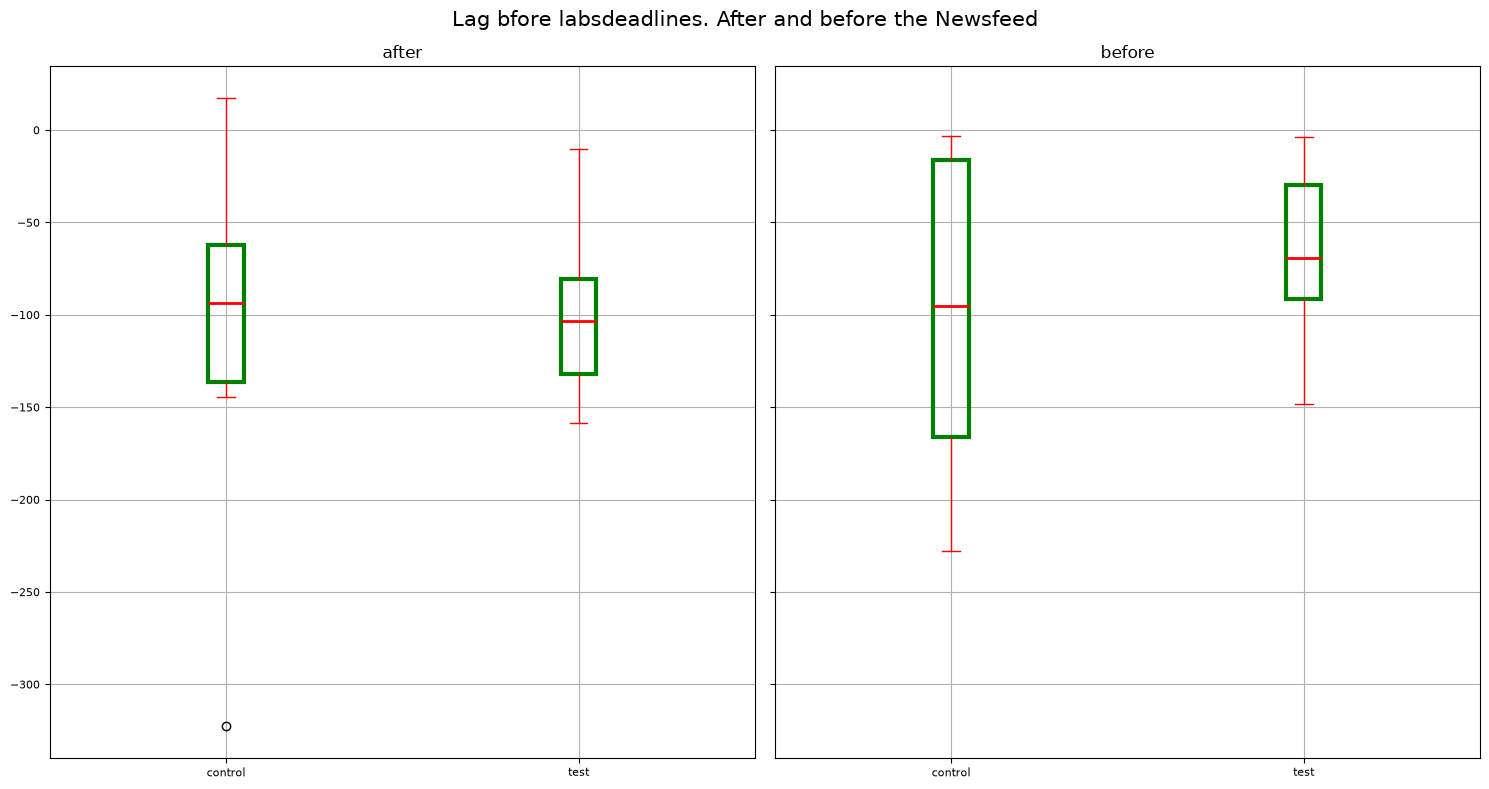

In [127]:
fig, (ax2, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(15, 8), sharey=True)
fig.suptitle('Lag bfore labsdeadlines. After and before the Newsfeed', fontsize=15, y=0.98)

data_before = [
    df_before[df_before['group'] == 'control']['diff'],
    df_before[df_before['group'] == 'test']['diff']
]
bp1 = ax1.boxplot(data_before, label=['control', 'test'], patch_artist=True, widths=0.1)
ax1.set_title('before')
ax1.grid()
ax1.tick_params(axis='both', labelsize=8)
ax1.set_xticklabels(['control', 'test'])
data_after = [
    df_after[df_after['group'] == 'control']['diff'],
    df_after[df_after['group'] == 'test']['diff']
]
bp2 = ax2.boxplot(data_after, label=['control', 'test'], patch_artist=True, widths=0.1)
ax2.set_title('after')
ax2.grid()
ax2.tick_params(axis='both', labelsize=8)
ax2.set_xticklabels(['control', 'test'])

for box in bp1['boxes']:
    box.set(facecolor='none', linewidth=3, edgecolor='green')
for whisker in bp1['whiskers']:
    whisker.set(color='red')
for cap in bp1['caps']:
    cap.set(color='red')
for median in bp1['medians']:
    median.set(color='red', linewidth=2)

for box in bp2['boxes']:
    box.set(facecolor='none', linewidth=3, edgecolor='green')
for whisker in bp2['whiskers']:
    whisker.set(color='red')
for cap in bp2['caps']:
    cap.set(color='red')
for median in bp2['medians']:
    median.set(color='red', linewidth=2)
    
plt.tight_layout()
plt.show()

In [111]:
conn.close()

Каков IQR (межквартильный размах) контрольной группы до появления ленты новостей?

Ответ: 150